# Centralized CNN Training on MNIST

## Objective

This notebook establishes a centralized learning baseline on the MNIST handwritten digit dataset.

The resulting accuracy serves as the benchmark for all subsequent Federated Learning experiments (FedAvg IID, FedAvg Non-IID, and FedProx).


In [4]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


## Environment Setup

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## Dataset

MNIST contains:
- 60,000 training images
- 10,000 test images
- 10 digit classes (0–9)
- 28×28 grayscale images


In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print('Train size:', len(train_dataset))
print('Test size:', len(test_dataset))


Train size: 60000
Test size: 10000


## Data Exploration

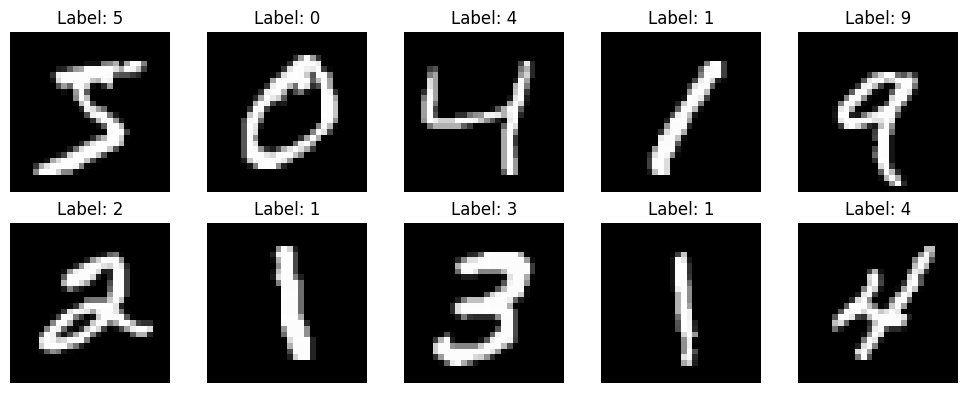

In [7]:
fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()


In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


## Model Architecture

CNN Architecture:
1. Conv2D (32 filters)
2. Conv2D (64 filters)
3. MaxPooling
4. Fully Connected Layer (128 neurons)
5. Output Layer (10 classes)


In [9]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))

        x = self.pool(x)
        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))

        return self.fc2(x)


## Training Configuration

- Optimizer: Adam
- Learning Rate: 0.001
- Loss Function: CrossEntropyLoss
- Epochs: 5
- Batch Size: 64


In [10]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 5


In [11]:
def train_model(model, loader, criterion, optimizer, epochs):

    losses = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)

        losses.append(epoch_loss)

        print(f'Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}')

    training_time = time.time() - start_time

    return losses, training_time


In [12]:
losses, training_time = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    EPOCHS
)


Epoch 1/5 Loss: 0.1506
Epoch 2/5 Loss: 0.0438
Epoch 3/5 Loss: 0.0271
Epoch 4/5 Loss: 0.0174
Epoch 5/5 Loss: 0.0133


## Training Loss

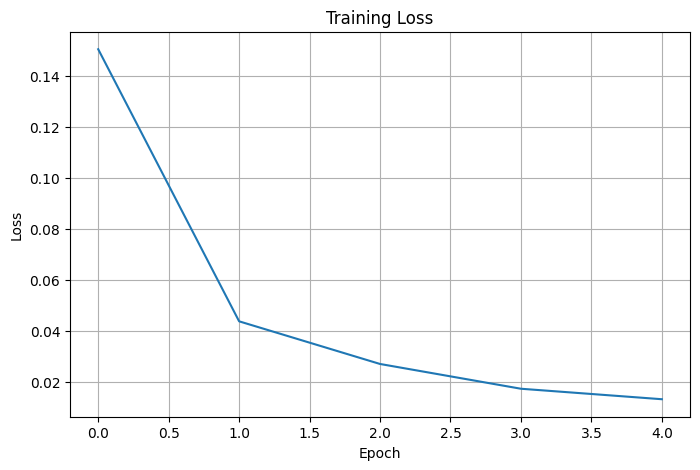

In [13]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.grid()

plt.savefig(
    'centralized_loss.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [14]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total


## Results

In [15]:
accuracy = evaluate(model, test_loader)

print(f'Accuracy      : {accuracy:.2f}%')
print(f'Training Time : {training_time:.2f} sec')


Accuracy      : 98.93%
Training Time : 445.84 sec


In [16]:
torch.save(
    model.state_dict(),
    'centralized_model.pth'
)


## Conclusion

The centralized CNN achieves approximately 99% accuracy on MNIST.

This result serves as the benchmark against which all Federated Learning experiments will be compared:

- FedAvg (IID)
- FedAvg (Non-IID)
- FedProx (Non-IID)
